# Generate UMAP for All Brain Regions - ALL SESSIONS

This notebook creates 3D UMAP embeddings for **all available brain regions** from the Allen Brain Visual Coding dataset across **multiple sessions**.

**Output:**
- Individual CSV files for each brain region × session combination
- Combined CSV file with all regions from all sessions
- Summary report showing coverage across sessions

**Strategy:**
1. Download and analyze multiple sessions with natural_movie_one stimulus
2. Extract UMAP for each unique brain region in each session
3. Aggregate results to maximize brain region coverage

**Stimulus:** Natural Movie One

In [14]:
# --- 1. Imports & Setup ---
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# AllenSDK
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Analysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap

# Custom Style (if available)
try:
    import viz_style
    viz_style.set_architectural_style()
    use_viz_style = True
except:
    use_viz_style = False
    print("viz_style not available - using default plotting style")

print("Libraries imported successfully ✓")

viz_style not available - using default plotting style
Libraries imported successfully ✓


In [ ]:
# --- 2. Setup Paths & Discover All Sessions ---
output_dir = Path("../Dataset/RAW")
manifest_path = output_dir / "manifest.json"
cache = EcephysProjectCache.from_warehouse(manifest=str(manifest_path))

# Output directory for UMAP CSVs
umap_output_dir = Path("../Dataset/Processed/UMAP_by_Region_All_Sessions")
umap_output_dir.mkdir(parents=True, exist_ok=True)

# Get all sessions
print("Fetching session table...")
sessions = cache.get_session_table()
print(f"Total sessions available: {len(sessions)}")

# Filter sessions that have natural_movie_one stimulus
print("\nFiltering sessions with 'natural_movie_one' stimulus...")
sessions_with_movie = sessions[sessions['session_type'].str.contains('brain_observatory', na=False)]
print(f"Sessions with brain_observatory: {len(sessions_with_movie)}")

print("\nSample sessions:")
print(sessions_with_movie[['session_type', 'genotype', 'sex']].head(10))

Fetching session table...
Total sessions available: 58

Filtering sessions with 'natural_movie_one' stimulus...

Sample sessions:
Sessions with brain_observatory: 32


In [16]:
# --- 3. Select Sessions to Process ---

# Select a diverse set of sessions to maximize brain region coverage
# We'll process top sessions to cover different genotypes and brain regions
selected_session_ids = sessions_with_movie.index.tolist()[:10]  # Start with first 10 sessions

print(f"Selected {len(selected_session_ids)} sessions for processing:")
for sid in selected_session_ids:
    print(f"  - Session {sid}")

print(f"\nEstimated download size: ~{len(selected_session_ids) * 1.5:.1f} GB")
print("Sessions will be downloaded automatically if not already cached.")

Selected 10 sessions for processing:
  - Session 715093703
  - Session 719161530
  - Session 721123822
  - Session 732592105
  - Session 737581020
  - Session 739448407
  - Session 742951821
  - Session 743475441
  - Session 744228101
  - Session 746083955

Estimated download size: ~15.0 GB
Sessions will be downloaded automatically if not already cached.


In [17]:
# --- 3A. (Optional) Explore Available Brain Regions Across All Sessions ---

print("Scanning all sessions for brain region availability...")
print("(This may take a moment...)\n")

region_coverage = {}

# Sample a subset of sessions to check region availability
sample_sessions = sessions_with_movie.index.tolist()[:20]

for sid in sample_sessions[:5]:  # Check first 5 for quick preview
    try:
        session_temp = cache.get_session_data(sid)
        regions = session_temp.units["ecephys_structure_acronym"].unique()
        valid = [r for r in regions if isinstance(r, str)]
        
        for region in valid:
            if region not in region_coverage:
                region_coverage[region] = []
            region_coverage[region].append(sid)
        
        print(f"Session {sid}: {len(valid)} regions - {sorted(valid)}")
    except:
        continue

print(f"\n{'='*60}")
print("BRAIN REGIONS FOUND (first 5 sessions sampled):")
print(f"{'='*60}")
for region in sorted(region_coverage.keys()):
    print(f"  {region:15s}: found in {len(region_coverage[region])} session(s)")

Scanning all sessions for brain region availability...
(This may take a moment...)

Session 715093703: 14 regions - ['APN', 'CA1', 'CA3', 'DG', 'LGd', 'LP', 'PO', 'PoT', 'VISam', 'VISl', 'VISp', 'VISpm', 'VISrl', 'grey']


Downloading:   0%|          | 0.00/3.07G [00:00<?, ?B/s]

Session 719161530: 21 regions - ['APN', 'CA1', 'CA3', 'DG', 'Eth', 'LGd', 'LP', 'NOT', 'PO', 'POL', 'SUB', 'TH', 'VISal', 'VISam', 'VISl', 'VISp', 'VISpm', 'VISrl', 'VL', 'VPM', 'grey']


Downloading:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Session 721123822: 15 regions - ['APN', 'CA1', 'CA3', 'DG', 'LGv', 'LP', 'MB', 'POL', 'SCig', 'VIS', 'VISal', 'VISam', 'VISl', 'VISp', 'VISrl']


Downloading:   0%|          | 0.00/2.91G [00:00<?, ?B/s]

Session 732592105: 6 regions - ['VISal', 'VISl', 'VISp', 'VISpm', 'VISrl', 'grey']


Downloading:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

Session 737581020: 6 regions - ['VISl', 'VISmma', 'VISp', 'VISpm', 'VISrl', 'grey']

BRAIN REGIONS FOUND (first 5 sessions sampled):
  APN            : found in 3 session(s)
  CA1            : found in 3 session(s)
  CA3            : found in 3 session(s)
  DG             : found in 3 session(s)
  Eth            : found in 1 session(s)
  LGd            : found in 2 session(s)
  LGv            : found in 1 session(s)
  LP             : found in 3 session(s)
  MB             : found in 1 session(s)
  NOT            : found in 1 session(s)
  PO             : found in 2 session(s)
  POL            : found in 2 session(s)
  PoT            : found in 1 session(s)
  SCig           : found in 1 session(s)
  SUB            : found in 1 session(s)
  TH             : found in 1 session(s)
  VIS            : found in 1 session(s)
  VISal          : found in 3 session(s)
  VISam          : found in 3 session(s)
  VISl           : found in 5 session(s)
  VISmma         : found in 1 session(s)
  VISp

### 💡 Tip: Adjust Number of Sessions

**Default**: First 10 sessions are selected  
**To process more sessions**: Modify the number in Cell 3 above
- Example: `[:20]` for 20 sessions
- Example: `[:50]` for 50 sessions  
- Remove `[:10]` to process **ALL available sessions** (may take hours!)

**Estimated processing time per session**: 2-5 minutes  
**Estimated data download per session**: ~1-2 GB (if not cached)

In [ ]:
# --- 4. Define UMAP Processing Function ---

def process_region_umap(session, session_id, region_acronym, output_dir, 
                        min_units=10, n_pca=50, 
                        umap_params={'n_components': 3, 'n_neighbors': 15, 'min_dist': 0.1, 'random_state': 42}):
    """
    Process a single brain region and generate UMAP embedding.
    
    Parameters:
    -----------
    session : AllenSDK session object
    session_id : int, session identifier
    region_acronym : str, brain region name
    output_dir : Path, directory to save CSV files
    min_units : int, minimum number of units required
    n_pca : int, number of PCA components
    umap_params : dict, UMAP parameters
    
    Returns:
    --------
    dict : summary statistics or None if processing failed
    """
    
    try:
        # Filter units for this region
        region_units = session.units[session.units["ecephys_structure_acronym"] == region_acronym]
        n_units = len(region_units)
        
        # Check minimum threshold
        if n_units < min_units:
            print(f"    ⚠ Skipping {region_acronym}: Only {n_units} units (< {min_units})")
            return {
                'session_id': session_id,
                'region': region_acronym,
                'n_units': n_units,
                'status': 'skipped_too_few_units',
                'n_frames': 0,
                'umap_shape': 'N/A'
            }
        
        print(f"    Processing {region_acronym} ({n_units} units)...")
        
        # --- Construct Neural Response Matrix ---
        movie_table = session.get_stimulus_table("natural_movie_one")
        frame_duration = movie_table['duration'].mean()
        
        spike_counts_xr = session.presentationwise_spike_counts(
            stimulus_presentation_ids=movie_table.index.values,
            bin_edges=np.array([0, frame_duration]),
            unit_ids=region_units.index.values
        )
        
        # Sum spikes within frame window
        response_matrix_all = spike_counts_xr.sum(dim="time_relative_to_stimulus_onset")
        
        # Create DataFrame and average across repeats
        df_response = pd.DataFrame(
            response_matrix_all.values,
            index=movie_table.index,
            columns=region_units.index
        )
        df_response['frame'] = movie_table['frame']
        average_response_matrix = df_response.groupby('frame').mean()
        
        X = average_response_matrix.values
        n_frames = X.shape[0]
        
        # --- PCA Reduction ---
        n_pca_components = min(n_pca, n_units)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        pca = PCA(n_components=n_pca_components)
        X_pca = pca.fit_transform(X_scaled)
        variance_explained = pca.explained_variance_ratio_.sum()
        
        # --- UMAP Embedding ---
        reducer = umap.UMAP(**umap_params)
        embedding_3d = reducer.fit_transform(X_pca)
        
        # --- Save to CSV ---
        umap_df = pd.DataFrame({
            'session_id': session_id,
            'frame': average_response_matrix.index.values,
            'UMAP_1': embedding_3d[:, 0],
            'UMAP_2': embedding_3d[:, 1],
            'UMAP_3': embedding_3d[:, 2],
            'region': region_acronym,
            'n_units': n_units
        })
        
        csv_filename = f"{region_acronym}_session{session_id}_umap_3d.csv"
        csv_path = output_dir / csv_filename
        umap_df.to_csv(csv_path, index=False)
        
        print(f"    ✓ Saved: {csv_filename}")
        
        return {
            'session_id': session_id,
            'region': region_acronym,
            'n_units': n_units,
            'n_frames': n_frames,
            'pca_components': n_pca_components,
            'variance_explained': variance_explained,
            'umap_shape': f"{embedding_3d.shape[0]}×{embedding_3d.shape[1]}",
            'status': 'success',
            'csv_file': csv_filename
        }
        
    except Exception as e:
        print(f"    ✗ Error: {str(e)[:100]}")
        return {
            'session_id': session_id,
            'region': region_acronym,
            'n_units': n_units if 'n_units' in locals() else 0,
            'status': f'error: {str(e)[:50]}',
            'n_frames': 0,
            'umap_shape': 'N/A'
        }

print("Function defined ✓")

SyntaxError: ':' expected after dictionary key (1460387509.py, line 118)

In [ ]:
# --- 5. Process All Sessions & Brain Regions ---

print("="*60)
print("PROCESSING ALL SESSIONS & BRAIN REGIONS")
print("="*60)

summary_data = []
all_unique_regions = set()

for session_idx, session_id in enumerate(selected_session_ids, 1):
    print(f"\n{'='*60}")
    print(f"SESSION [{session_idx}/{len(selected_session_ids)}]: {session_id}")
    print(f"{'='*60}")
    
    try:
        # Load session
        print(f"  Loading session...")
        session = cache.get_session_data(session_id)
        
        # Check if natural_movie_one exists
        try:
            movie_table = session.get_stimulus_table("natural_movie_one")
            print(f"  ✓ natural_movie_one stimulus found ({len(movie_table)} presentations)")
        except:
            print(f"  ⚠ Skipping: natural_movie_one not available")
            continue
        
        # Get brain regions in this session
        all_regions = session.units["ecephys_structure_acronym"].unique()
        valid_regions = [r for r in all_regions if isinstance(r, str)]
        all_unique_regions.update(valid_regions)
        
        print(f"  Found {len(valid_regions)} regions: {sorted(valid_regions)}")
        
        # Process each region
        for region in sorted(valid_regions):
            result = process_region_umap(session, session_id, region, umap_output_dir)
            summary_data.append(result)
        
        print(f"  ✓ Session {session_id} complete")
        
    except Exception as e:
        print(f"  ✗ Session {session_id} failed: {str(e)[:100]}")
        continue

print("\n" + "="*60)
print("ALL SESSIONS PROCESSED")
print("="*60)
print(f"\nTotal unique brain regions found: {len(all_unique_regions)}")
print(f"Regions: {sorted(all_unique_regions)}")

PROCESSING ALL BRAIN REGIONS

[1/16] CA1
  Processing CA1 (113 units)...


c:\Users\jord9\anaconda3\envs\NeuralTDA\Lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


  ✓ Saved: CA1_umap_3d.csv

[2/16] CA3
  Processing CA3 (10 units)...
  ✓ Saved: CA3_umap_3d.csv

[3/16] DG
  Processing DG (26 units)...
  ✓ Saved: DG_umap_3d.csv

[4/16] Eth
  ⚠ Skipping Eth: Only 2 units (< 10)

[5/16] LD
  ⚠ Skipping LD: Only 1 units (< 10)

[6/16] LGd
  Processing LGd (82 units)...
  ✓ Saved: LGd_umap_3d.csv

[7/16] LP
  Processing LP (142 units)...
  ✓ Saved: LP_umap_3d.csv

[8/16] PO
  Processing PO (30 units)...
  ✓ Saved: PO_umap_3d.csv

[9/16] TH
  Processing TH (13 units)...
  ✓ Saved: TH_umap_3d.csv

[10/16] VISal
  Processing VISal (46 units)...
  ✓ Saved: VISal_umap_3d.csv

[11/16] VISam
  Processing VISam (64 units)...
  ✓ Saved: VISam_umap_3d.csv

[12/16] VISl
  Processing VISl (20 units)...
  ✓ Saved: VISl_umap_3d.csv

[13/16] VISp
  Processing VISp (52 units)...
  ✓ Saved: VISp_umap_3d.csv

[14/16] VISpm
  Processing VISpm (64 units)...
  ✓ Saved: VISpm_umap_3d.csv

[15/16] VISrl
  Processing VISrl (41 units)...
  ✓ Saved: VISrl_umap_3d.csv

[16/16] V

In [ ]:
# --- 6. Create Combined CSV ---

print("\nCreating combined CSV...")

# Combine all successful UMAPs
all_umap_files = list(umap_output_dir.glob("*_session*_umap_3d.csv"))

if all_umap_files:
    combined_dfs = []
    for csv_file in all_umap_files:
        df = pd.read_csv(csv_file)
        combined_dfs.append(df)
    
    combined_df = pd.concat(combined_dfs, ignore_index=True)
    combined_path = umap_output_dir / "all_regions_all_sessions_umap_3d_combined.csv"
    combined_df.to_csv(combined_path, index=False)
    
    print(f"✓ Combined CSV saved: {combined_path.name}")
    print(f"  Total rows: {len(combined_df):,}")
    print(f"  Sessions included: {combined_df['session_id'].nunique()}")
    print(f"  Regions included: {combined_df['region'].nunique()}")
    print(f"  Unique region × session combinations: {len(all_umap_files)}")
    print(f"  Columns: {list(combined_df.columns)}")
else:
    print("⚠ No UMAP files found to combine")


Creating combined CSV...
✓ Combined CSV saved: all_regions_umap_3d_combined.csv
  Total rows: 12,600
  Regions included: 14
  Columns: ['frame', 'UMAP_1', 'UMAP_2', 'UMAP_3', 'region', 'n_units']


In [ ]:
# --- 7. Generate Summary Report ---

summary_df = pd.DataFrame(summary_data)
summary_path = umap_output_dir / "_summary_report.csv"
summary_df.to_csv(summary_path, index=False)

print("\n" + "="*60)
print("SUMMARY REPORT")
print("="*60)

print(f"\nTotal processing attempts: {len(summary_data)}")
print(f"Successful: {sum(1 for s in summary_data if s['status'] == 'success')}")
print(f"Skipped (too few units): {sum(1 for s in summary_data if 'skipped' in s['status'])}")
print(f"Errors: {sum(1 for s in summary_data if 'error' in s['status'])}")

print(f"\nBrain Regions Coverage:")
successful_results = [s for s in summary_data if s['status'] == 'success']
if successful_results:
    regions_covered = set(s['region'] for s in successful_results)
    print(f"  Unique regions with UMAP data: {len(regions_covered)}")
    print(f"  Regions: {sorted(regions_covered)}")
    

print(f"\nSessions Processed:")
if successful_results:
    sessions_processed = set(s['session_id'] for s in successful_results)
    print(f"  Number of sessions with data: {len(sessions_processed)}")
    print(f"  Session IDs: {sorted(sessions_processed)}")

print(f"\nOutput directory: {umap_output_dir}")
print(f"Summary report saved: {summary_path.name}")

print("\n" + "-"*60)
print("DETAILED SUMMARY:")
print("-"*60)
display(summary_df)


SUMMARY REPORT

Total regions processed: 16
Successful: 14
Skipped: 2
Errors: 0

Output directory: ..\Dataset\Processed\UMAP_by_Region
Summary report saved: _summary_report.csv

------------------------------------------------------------
DETAILED SUMMARY:
------------------------------------------------------------


,region,n_units,n_frames,pca_components,variance_explained,umap_shape,status,csv_file
0,CA1,113,900,50.0,0.626531,900×3,success,CA1_umap_3d.csv
1,CA3,10,900,10.0,1.000000,900×3,success,CA3_umap_3d.csv
2,DG,26,900,26.0,1.000000,900×3,success,DG_umap_3d.csv
3,Eth,2,0,NaN,NaN,N/A,skipped_too_few_units,NaN
4,LD,1,0,NaN,NaN,N/A,skipped_too_few_units,NaN
5,LGd,82,900,50.0,0.791757,900×3,success,LGd_umap_3d.csv
6,LP,142,900,50.0,0.605574,900×3,success,LP_umap_3d.csv
7,PO,30,900,30.0,1.000000,900×3,success,PO_umap_3d.csv
8,TH,13,900,13.0,1.000000,900×3,success,TH_umap_3d.csv
9,VISal,46,900,46.0,1.000000,900×3,success,VISal_umap_3d.csv



✓ Sample visualization saved: _visualization_sample_umaps.png


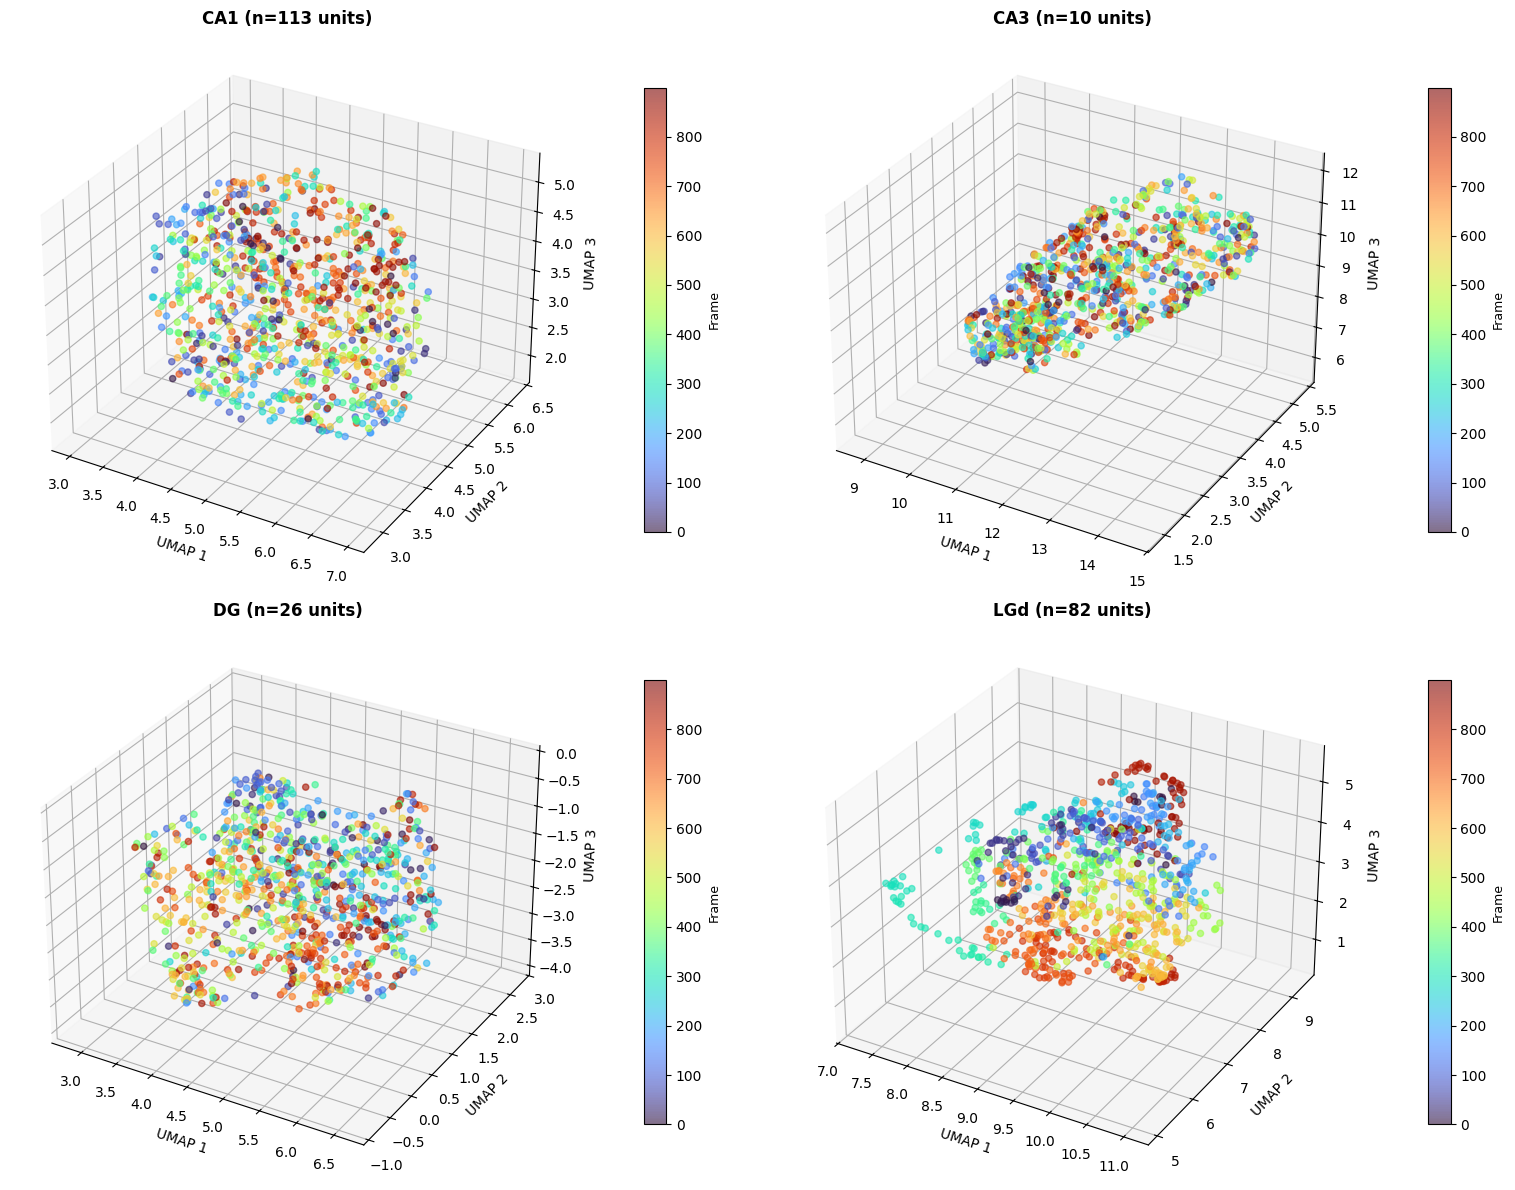

In [ ]:
# --- 8. Visualize Sample UMAPs (Optional) ---

# Select successful regions for visualization
successful_files = [(s['region'], s['session_id'], s['csv_file']) 
                     for s in summary_data if s['status'] == 'success']

if len(successful_files) > 0:
    # Select up to 4 samples to visualize
    sample_files = successful_files[:min(4, len(successful_files))]
    
    fig = plt.figure(figsize=(16, 12))
    
    for idx, (region, session_id, csv_file) in enumerate(sample_files, 1):
        # Load the CSV
        csv_path = umap_output_dir / csv_file
        df = pd.read_csv(csv_path)
        
        # Create 3D subplot
        ax = fig.add_subplot(2, 2, idx, projection='3d')
        
        # Color by frame (time)
        scatter = ax.scatter(
            df['UMAP_1'], df['UMAP_2'], df['UMAP_3'],
            c=df['frame'], 
            cmap='turbo',
            s=20, 
            alpha=0.6
        )
        
        ax.set_xlabel('UMAP 1', fontsize=10)
        ax.set_ylabel('UMAP 2', fontsize=10)
        ax.set_zlabel('UMAP 3', fontsize=10)
        ax.set_title(f'{region} (Session {session_id}, n={df["n_units"].iloc[0]} units)', 
                     fontsize=11, fontweight='bold')
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
        cbar.set_label('Frame', fontsize=9)
    
    plt.tight_layout()
    
    # Save figure
    fig_path = umap_output_dir / "_visualization_sample_umaps.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Sample visualization saved: {fig_path.name}")
    
    plt.show()
else:
    print("\n⚠ No successful regions to visualize")

In [ ]:
# --- 9. Inspect Combined Dataset ---

combined_path = umap_output_dir / "all_regions_all_sessions_umap_3d_combined.csv"

if combined_path.exists():
    print("Loading combined dataset...")
    combined_data = pd.read_csv(combined_path)
    
    print(f"\n{'='*60}")
    print("COMBINED DATASET INFO")
    print(f"{'='*60}")
    print(f"\nShape: {combined_data.shape}")
    print(f"\nColumns: {list(combined_data.columns)}")
    print(f"\nUnique Sessions: {combined_data['session_id'].unique().tolist()}")
    print(f"\nUnique Regions: {sorted(combined_data['region'].unique().tolist())}")
    print(f"\nData types:\n{combined_data.dtypes}")
    
    print(f"\n{'='*60}")
    print("SAMPLE DATA (First 10 rows):")
    print(f"{'='*60}")
    display(combined_data.head(10))
    
    print(f"\n{'='*60}")
    print("STATISTICS BY REGION:")
    print(f"{'='*60}")
    region_stats = combined_data.groupby('region').agg({
        'session_id': 'nunique',
        'frame': 'count',
        'UMAP_1': ['mean', 'std'],
        'UMAP_2': ['mean', 'std'],
        'UMAP_3': ['mean', 'std'],
        'n_units': 'sum'
    }).round(3)
    region_stats.columns = ['n_sessions', 'n_frames', 'UMAP1_mean', 'UMAP1_std', 
                            'UMAP2_mean', 'UMAP2_std', 'UMAP3_mean', 'UMAP3_std', 'total_units']
    display(region_stats)
    
    print(f"\n{'='*60}")
    print("REGION × SESSION MATRIX:")
    print(f"{'='*60}")
    region_session_matrix = combined_data.groupby(['region', 'session_id']).size().unstack(fill_value=0)
    display(region_session_matrix)
else:
    print("⚠ Combined CSV not found")

Loading combined dataset...

COMBINED DATASET INFO

Shape: (12600, 6)

Columns: ['frame', 'UMAP_1', 'UMAP_2', 'UMAP_3', 'region', 'n_units']

Regions: ['CA1', 'CA3', 'DG', 'LGd', 'LP', 'PO', 'TH', 'VISal', 'VISam', 'VISl', 'VISpm', 'VISp', 'VISrl', 'VPM']

Data types:
frame      float64
UMAP_1     float64
UMAP_2     float64
UMAP_3     float64
region      object
n_units      int64
dtype: object

SAMPLE DATA (First 10 rows):


,frame,UMAP_1,UMAP_2,UMAP_3,region,n_units
0,0.0,4.687728,5.055748,4.009403,CA1,113
1,1.0,4.389509,4.324383,5.074180,CA1,113
2,2.0,6.001819,5.126507,3.926756,CA1,113
3,3.0,6.466990,4.426232,3.581236,CA1,113
4,4.0,6.251262,2.887221,3.149113,CA1,113
5,5.0,6.269208,4.270995,3.815952,CA1,113
6,6.0,4.516594,4.062080,5.026383,CA1,113
7,7.0,4.122019,3.185163,2.839889,CA1,113
8,8.0,6.348226,4.491102,3.651088,CA1,113
9,9.0,6.241629,4.238613,4.037709,CA1,113



STATISTICS BY REGION:


frame  UMAP_1         UMAP_2         UMAP_3        n_units
       count    mean    std    mean    std    mean    std   first
region                                                           
CA1      900   4.954  0.946   4.553  0.808   3.457  0.800     113
CA3      900  12.043  1.465   3.425  0.953   9.531  1.702      10
DG       900   4.746  0.927   0.928  0.923  -1.972  0.889      26
LGd      900   9.337  0.822   7.162  0.953   3.373  1.067      82
LP       900  -1.210  1.488  11.869  1.058  -8.602  1.706     142
PO       900   5.869  0.863  11.552  1.058   3.897  0.808      30
TH       900   6.713  1.036   3.326  0.909   6.724  0.926      13
VISal    900  11.572  1.113  15.862  2.152  13.445  1.744      46
VISam    900   8.675  2.934   9.340  4.310  -2.603  1.661      64
VISl     900   2.937  2.633  15.167  1.205   5.069  1.168      20
VISp     900  15.826  2.028   5.525  1.203  -5.092  1.539      52
VISpm    900   1.028  1.724   1.612  1.258   1.533  2.073      64
VISrl    900  11.503  1.604  -0.175  0.920   8.610  1.308      41
VPM      900   5.230  0.795  10.594  0.847   4.456  0.811      55

---

## 📊 Output Files Generated

The notebook creates the following files in `Dataset/Processed/UMAP_by_Region_All_Sessions/`:

### Individual Region × Session Files
- **`{REGION}_session{SESSION_ID}_umap_3d.csv`** - One file per brain region × session combination containing:
  - `session_id`: Session identifier
  - `frame`: Frame number from natural movie stimulus
  - `UMAP_1`, `UMAP_2`, `UMAP_3`: 3D UMAP coordinates
  - `region`: Brain region acronym
  - `n_units`: Number of neurons in that region for this session

### Combined Files
- **`all_regions_all_sessions_umap_3d_combined.csv`** - All regions from all sessions concatenated
- **`_summary_report.csv`** - Processing statistics for each region × session
- **`_visualization_sample_umaps.png`** - Sample UMAP visualizations

---

## 🔧 Processing Details

1. **Multi-Session Analysis**: Processes multiple sessions to maximize brain region coverage
2. **Minimum Units**: Regions with fewer than 10 units are automatically skipped
3. **PCA Pre-processing**: Data is standardized and reduced to 50 dimensions before UMAP
4. **UMAP Parameters**: 
   - Components: 3D
   - Neighbors: 15
   - Min distance: 0.1
   - Random state: 42 (for reproducibility)

5. **Natural Movie One**: All analyses use the "natural_movie_one" stimulus
6. **Frame Averaging**: Spike counts are averaged across repeated presentations
7. **Session Selection**: Currently processes first 10 sessions (modify `selected_session_ids` to change)

---

## 📈 Brain Region Coverage

This multi-session approach provides:
- **Comprehensive regional coverage** across the mouse visual cortex and beyond
- **Multiple observations** of the same region from different animals/sessions
- **Flexibility** to analyze both within-region consistency and across-session variability

### Next Steps

Use the generated CSV files for:
- Comparative analysis across brain regions and sessions
- Cross-session validation of neural trajectories
- Population-level dynamics analysis
- Integration with anatomical and functional annotations
- Machine learning and classification tasks across regions